# Spectral decomposition of drifter trajectories


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, images_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from rasterio.transform import Affine

import pynsitu as pyn

_____
# Isolate the different spectral components

In [2]:
ds = xr.open_dataset('/Users/mdemol/DATA_DRIFTERS/drifters_harmonized_old/L2/all_med_variational_10min_v0.nc').set_coords('drifter_type')
ds['drifter_id'] = ds.drifter_id.astype(str)

def filter_traj(ds, T=20, cutoff = { 'HF':[2.2, 70.95], 'LF': [0.88],'inertial':[1.05, 1.75], 'diurnal' : [0.88, 1.05], 'semidiurnal':[1.9, 2.1],}):
    """Return dataset with filtered trajectories acceleration and coriolis term (inertial, diurnal, semidiurnal)
    T: window length days
    """
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize
    
    # coefficients
    dt = 1/24/6  # 10min in days
    numtaps = int(T / dt)
    pass_zero = False


    # filter
    dss = ds.fillna(0)
    for c in cutoff : 
        if c == 'LF' : pass_zero = True
        #elif c == 'HF' : pass_zero = 'highpass'
        else : pass_zero = False
 
        taps = signal.firwin(numtaps, cutoff=cutoff[c], pass_zero=pass_zero, fs=1 / dt, scale=True)
        dss[c+'_velocity_east'] = xr.DataArray(
            filtfilt(taps, 1, dss.velocity_east),
            dims=["drifter_id", "datetime"],
            )
        dss[c+'_velocity_north'] = xr.DataArray(
            filtfilt(taps, 1, dss.velocity_north),
            dims=["drifter_id","datetime"],
            )
        dss[c+'_acceleration_east'] = (
            (dss[c+'_velocity_east'].differentiate("datetime", datetime_unit = '1s'))
            .assign_attrs(**ds.acceleration_east.attrs)
        )
        dss[c+'_acceleration_north'] = (
            (dss[c+'_velocity_north'].differentiate("datetime", datetime_unit = '1s'))
            .assign_attrs(**ds.acceleration_north.attrs)
        )
        print(c)
    
    return dss


In [4]:
ds

<xarray.Dataset> Size: 788MB
Dimensions:             (drifter_id: 162, datetime: 43406)
Coordinates:
    drifter_type        (drifter_id) <U7 5kB ...
  * datetime            (datetime) datetime64[ns] 347kB 2023-03-27T12:50:00 ....
  * drifter_id          (drifter_id) <U15 10kB '4388938' '4694122' ... '4694474'
Data variables: (12/17)
    x                   (drifter_id, datetime) float64 56MB ...
    y                   (drifter_id, datetime) float64 56MB ...
    cruise_id           (drifter_id) <U9 6kB ...
    lonc                (drifter_id) float64 1kB ...
    latc                (drifter_id) float64 1kB ...
    longitude           (drifter_id, datetime) float64 56MB ...
    ...                  ...
    acceleration_north  (drifter_id, datetime) float64 56MB ...
    acceleration        (drifter_id, datetime) float64 56MB ...
    X                   (drifter_id, datetime) float64 56MB ...
    gap_mask            (drifter_id, datetime) float64 56MB ...
    gaps                (drifter_id, datetime) float64 56MB ...
    sign_acceleration   (drifter_id, datetime) float64 56MB ...
Attributes:
    description:                     L2 product - applied smoothing method on...
    smoothing_method:                Variational
    smoothing_method_param_dict:     {'acc_cut': 0.0003, 'position_error': 70...
    interpolation_sampling:          10min
    version:                         v0
    geographical_projection:         Asimuthal Equidistant projection centere...
    geographical_projection_pyproj:  pyproj.Proj(proj="aeqd", lat_0=latc, lon...
    citation_str:                    
    distribution_str:                These data were collected and made freel...
    generation_date:                 2024-09-30 08:37:54.325171

In [5]:
ds = ds.isel(drifter_id = slice(0,10))

In [6]:
dsi = filter_traj(ds)

HF
LF
inertial
diurnal
semidiurnal


In [4]:
#dsi['other_velocity_east'] = dsi.velocity_east-dsi.inertial_velocity_east-dsi.diurnal_velocity_east-dsi.semidiurnal_velocity_east-dsi.LF_velocity_east
#dsi['Hther_velocity_north'] = dsi.velocity_north-dsi.inertial_velocity_north-dsi.diurnal_velocity_north-dsi.semidiurnal_velocity_north-dsi.LF_velocity_north

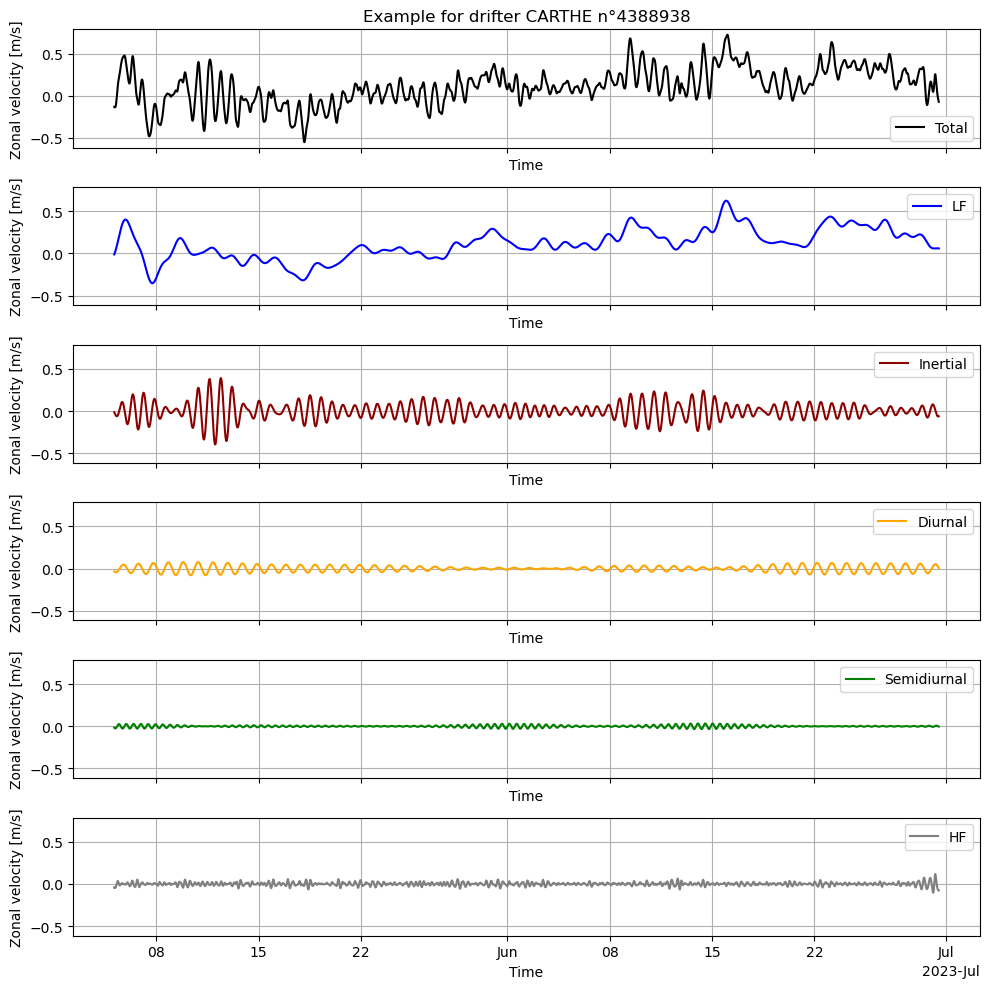

In [4]:
i=0
dsi_ = dsi.where(ds.gap_mask==1).isel(drifter_id =i)

fig, axs= plt.subplots(6, 1, figsize=(10, 10), sharex=True, sharey=True, frameon=False)
ax = axs[0]
dsi_.velocity_east.plot(label='Total', ax=ax, c='k')
ax = axs[1]
dsi_.LF_velocity_east.plot(label='LF', ax=ax, c='blue')
ax = axs[2]
dsi_.inertial_velocity_east.plot(label='Inertial', ax=ax, c='darkred')
ax = axs[3]
dsi_.diurnal_velocity_east.plot(label='Diurnal', ax=ax,c = 'orange')
ax = axs[4]
dsi_.semidiurnal_velocity_east.plot(label='Semidiurnal', ax=ax, c = 'green')
ax = axs[5]
(dsi_.HF_velocity_east).plot(label='HF', ax=ax,c = 'grey')
for ax in axs : 
    ax.grid()
    ax.legend()
    ax.set_title('')
    ax.set_ylabel('Zonal velocity [m/s]')
    ax.set_xlabel('Time')
axs[0].set_title(f'Example for drifter {dsi_.drifter_type.values} n°{dsi_.drifter_id.values}')
fig.tight_layout()
fig.savefig(os.path.join(images_dir, 'spectral_decomp_zonal_velocities.png'))

______
# Spectra

In [7]:
from sstats import tseries as ts
rename_forspectra = {'datetime':'time', 'drifter_id':'id'}
def spectrum_ds(ds, nperseg="10D", detrend=False, vc = [("velocity_east", "velocity_north"),  ("LF_velocity_east", "LF_velocity_north"),("acceleration_east", "acceleration_north"), ("inertial_velocity_east", "inertial_velocity_north"), ("diurnal_velocity_east", "diurnal_velocity_north"), ("semidiurnal_velocity_east", "semidiurnal_velocity_north"), ("HF_velocity_east", "HF_velocity_north")]):
    ds = ds.rename(rename_forspectra)
    #ds = df.reset_index().set_index(["time", "id"]).to_xarray()
    E = []
    for tup in vc:
        ds_ = ds.fillna(0).ts.spectrum(unit="1D", nperseg=nperseg, detrend=detrend, complex=tup)
        E.append(ds_)
    return xr.merge(E)
dss = spectrum_ds(dsi.fillna(0), nperseg="20D", detrend=False)

In [8]:
dss

<xarray.Dataset> Size: 2MB
Dimensions:                                               (id: 10,
                                                           frequency: 2880)
Coordinates:
    drifter_type                                          (id) <U7 280B 'CART...
  * id                                                    (id) <U15 600B '438...
  * frequency                                             (frequency) float64 23kB ...
Data variables:
    velocity_east_velocity_north                          (id, frequency) float64 230kB ...
    LF_velocity_east_LF_velocity_north                    (id, frequency) float64 230kB ...
    acceleration_east_acceleration_north                  (id, frequency) float64 230kB ...
    inertial_velocity_east_inertial_velocity_north        (id, frequency) float64 230kB ...
    diurnal_velocity_east_diurnal_velocity_north          (id, frequency) float64 230kB ...
    semidiurnal_velocity_east_semidiurnal_velocity_north  (id, frequency) float64 230kB ...
    HF_velocity_east_HF_velocity_north                    (id, frequency) float64 230kB ...

In [6]:
def negpos_spectra(ds, freqkey="frequency"):
    """Return two datasets with cyclonic/anticyclonic spectra"""
    ds_inv = ds.sortby(freqkey, ascending=False)
    dsneg = ds_inv.where(ds_inv[freqkey] <= 0, drop=True)
    dsneg[freqkey] = -dsneg[freqkey]
    dspos = ds.where(ds[freqkey] >= 0, drop=True)
    return dsneg, dspos

dss = sum(negpos_spectra(dss, freqkey="frequency"))

In [7]:
dss

<xarray.Dataset> Size: 13MB
Dimensions:                                               (id: 162,
                                                           frequency: 1440)
Coordinates:
  * id                                                    (id) <U15 10kB '438...
  * frequency                                             (frequency) float64 12kB ...
    drifter_type                                          (id) <U7 5kB 'CARTH...
Data variables:
    velocity_east_velocity_north                          (id, frequency) float64 2MB ...
    LF_velocity_east_LF_velocity_north                    (id, frequency) float64 2MB ...
    acceleration_east_acceleration_north                  (id, frequency) float64 2MB ...
    inertial_velocity_east_inertial_velocity_north        (id, frequency) float64 2MB ...
    diurnal_velocity_east_diurnal_velocity_north          (id, frequency) float64 2MB ...
    semidiurnal_velocity_east_semidiurnal_velocity_north  (id, frequency) float64 2MB ...
    HF_velocity_east_HF_velocity_north                    (id, frequency) float64 2MB ...

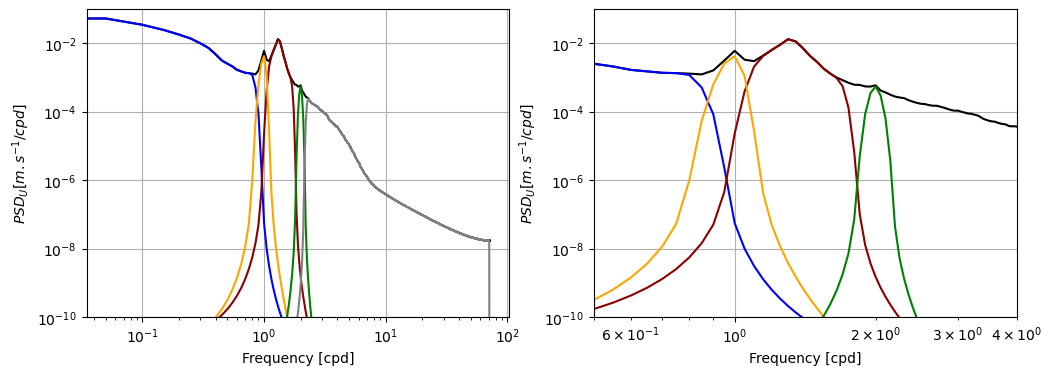

In [8]:
linthresh = 1e-1
linscale = 0.3
fig, axs = plt.subplots(1, 2, figsize=(12, 4), frameon=False)
fc = -pyn.geo.coriolis(ds.latitude.mean()) * 86400 / 2 / np.pi
fcmax = -pyn.geo.coriolis(ds.latitude.max()) * 86400 / 2 / np.pi
fcmin = -pyn.geo.coriolis(ds.latitude.min()) * 86400 / 2 / np.pi
fcbmin = - 0.70074557
fcbmax = - 1.90074557

ax = axs[0]
dss.velocity_east_velocity_north.mean("id").plot(ax=ax,label = 'Total', c='k')
dss.LF_velocity_east_LF_velocity_north.mean("id").plot(ax=ax,label ='LF', c='blue')
dss.inertial_velocity_east_inertial_velocity_north.mean("id").plot(ax=ax,label ='Inertial', c='darkred')
dss.diurnal_velocity_east_diurnal_velocity_north.mean("id").plot(ax=ax,label ='Diurnal', c='orange')
dss.semidiurnal_velocity_east_semidiurnal_velocity_north.mean("id").plot(ax=ax,label ='Semidiurnal', c='green')
dss.HF_velocity_east_HF_velocity_north.mean("id").plot(ax=ax,label ='HF', c='grey')
#dss.other_velocity_east_other_velocity_north.mean("id").plot(ax=ax,)
ax.set_ylabel(r"$PSD_{U} [m.s^{-1}/cpd]$")
ax.set_xlabel("Frequency [cpd]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid()
ax.set_ylim(1e-10, 1e-1)
#ax.set_xlim(-24 * 60 / 30 / 2, 24 * 60 / 30 / 2)
ax.set_title("")
#ax.axvline(fc, ls=':', c='r', label='Inertial frequency')
#ax.axvline(fcmax, ls=':', c='r', label='Max Inertial frequency')
#ax.axvline(fcmin, ls=':', c='r', label='Min Inertial frequency')
#ax.axvline(fcbmax, ls=':', c='g', label='Max Inertial frequency')
#ax.axvline(fcbmin, ls=':', c='g', label='Min Inertial frequency')

ax = axs[1]
dss.velocity_east_velocity_north.mean("id").plot(ax=ax,label = 'Total', c='k')
dss.LF_velocity_east_LF_velocity_north.mean("id").plot(ax=ax,label ='LF', c='blue')
dss.inertial_velocity_east_inertial_velocity_north.mean("id").plot(ax=ax,label ='Inertial', c='darkred')
dss.diurnal_velocity_east_diurnal_velocity_north.mean("id").plot(ax=ax,label ='Diurnal', c='orange')
dss.semidiurnal_velocity_east_semidiurnal_velocity_north.mean("id").plot(ax=ax,label ='Semidiurnal', c='green')
#dss.velocity_east_other_velocity_north.mean("id").plot(ax=ax,)
ax.set_ylabel(r"$PSD_{U} [m.s^{-1}/cpd]$")
ax.set_xlabel("Frequency [cpd]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid()
ax.set_xlim(5e-1, 4)
ax.set_ylim(1e-10, 1e-1)
#ax.set_xlim(-24 * 60 / 30 / 2, 24 * 60 / 30 / 2)
ax.set_title("")
#ax.axvline(fc, ls=':', c='r', label='Inertial frequency')
#ax.axvline(fcmax, ls=':', c='r', label='Max Inertial frequency')
#ax.axvline(fcmin, ls=':', c='r', label='Min Inertial frequency')
#ax.axvline(fcbmax, ls=':', c='g', label='Max Inertial frequency')
#ax.axvline(fcbmin, ls=':', c='g', label='Min Inertial frequency')
fig.savefig(os.path.join(images_dir, 'spectral_decomp_PSDu.png'))

____
# Store

In [9]:
dsi['longitude']= ds['longitude']
dsi.where(ds.gap_mask==1).to_netcdf(os.path.join(zarr_dir,'before_coloc', 'spectral_decomp_all_med_variational_10min_v0.nc'))